# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [56]:
# Your Phase 1 solution to the problem goes here.


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [58]:
#look at airbnb data
df = pd.read_csv('data/airbnb_hw.csv')
print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

df.head()

df["Price"] = df["Price"].astype(str).replace('[\$,]', '', regex=True).astype(float)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print(df)

df['Price'].isna().sum()

df.shape:
(30478, 13) 

df.dtypes:
Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                             str
Review Scores Rating          float64
dtype: object 

        Host Id Host Since                                Name Neighbourhood   \
0       5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1      33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2      39608626        NaN                Sunny Room in Harlem      Manhattan   
3           500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4           500  6/26/2008            Trendy Times

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/var/folders/z4/qqnkb_zs73n18_x_00kpyxpw0000gn/T/ipykernel_36800/4267884298.py:11: SyntaxWarning: invalid escape sequence '\$'
  df["Price"] = df["Price"].astype(str).replace('[\$,]', '', regex=True).astype(float)


np.int64(0)

In [59]:
#Question 1 part 2 
#Examine Minnisota police data 
df = pd.read_csv('data/mn_police_use_of_force.csv')
print("df.shape:")
print(df.shape, '\n')

df.head()

#check for nulls/na's in the subject injury column 
df['subject_injury'].isnull().sum()

#get total number of rows in the dataset
total_rows = df.shape[0]

#proportion of rows with null values in the subject injury column
missing_count = df['subject_injury'].isna().sum()
total_rows = len(df)
proportion_missing = missing_count / total_rows
print(proportion_missing)

#SO about 71 percent of rows in the subject_injury column are missing values. This is a very large amount of missing data, which is concerning as it limits the kind of preparation the precinct can take to prepare for most common injuries. 

#clean subject_injury by replacing any nulls with "not known"
df['subject_injury'] = df['subject_injury'].fillna('not known')


#cross tabulate the subject_injury column with the force_type to see if there is a correlation between missing values 
pd.crosstab(df['subject_injury'], df['force_type'])

#this shows that there appear to be the most unknown injuries reported when the force type involves wither bodily force or a chemical irritant (I am assuming this is something like pepper spray). Those injuries are likely more minor than those from a firearm or improvised weapon, and therefore the officers may be less likely to report an injury. They may also be less likely to report an injury if they feel it would reflect poorly on them, althought that is of course just an idea, and would need far more data and analysis. 



df.shape:
(12925, 13) 

0.7619342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
not known,2,7051,1421,0,27,74,87,0,170,31,985


5 2026
              Date  Year        Type           Country  \
0      26th August  2026  Unprovoked               USA   
1     23rd August   2026  Unprovoked               USA   
2      19th August  2026    Provoked    Reunion Island   
3      11th August  2026    Provoked           Ireland   
4       8th August  2026  Unprovoked               USA   
...            ...   ...         ...               ...   
5578          1940  1940  Unprovoked        NEW GUINEA   
5579          1940  1940  Unprovoked  PAPUA NEW GUINEA   
5580          1940  1940     Invalid      SOUTH AFRICA   
5581          1940  1940     Invalid      SOUTH AFRICA   
5582          1940  1940     Invalid      SOUTH AFRICA   

                        State                             Location  \
0                      Hawaii          Ala Moana Beach Park, Oah'u   
1                     Florida     Boca Grande (island in the keys)   
2     Saint-Gilles-les-Baines             Outer Reef Roches Noires   
3               

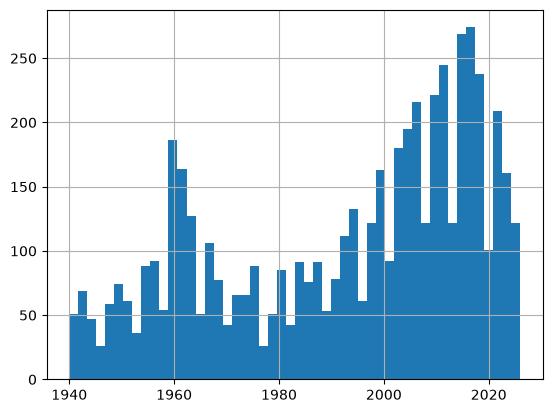

In [60]:
#Question 2 
#examine the shark attack data
df = pd.read_excel('data/GSAF5.xls')


#drop empty columns 
df = df.dropna(axis=1, how='all')

df.head()

#clean years column by converting to integers
df['Year'] = df['Year'].astype('Int64')
#drop zero years, as in looking at the data set, it is noted that we do not have a date recorded for those. 
df = df[df['Year'] != 0]

#display range of years
print(df['Year'].min(), df['Year'].max())

df_since_1940 = df[df['Year'] >= 1940]
print(df_since_1940)

#make a histogram to examine trends since 1940
print('Before coercion:\n', df_since_1940['Year'].describe(), '\n')
df_since_1940['Year'].hist(bins=50)

#determine proportion of victims who are male
df['Sex'].value_counts(normalize=True) * 100
sex_proportion= df['Sex'].value_counts(normalize=True)
male_proportion = sex_proportion.loc['M'] 
print(f"The proportion of victims who are male is {male_proportion:.2%}")

#clean the Type column 
#determine what values are in the Type column
df['Type'].value_counts()

#replace the values in the Type column with more only provoked, unprovoked, and unknown
df['Type'] = df['Type'].str.strip()  

df['Type'] = df['Type'].replace({
    'Unprovoked': 'Unprovoked',
    'UNprovoked': 'Unprovoked',
    'unprovoked': 'Unprovoked',
    'Provoked': 'Provoked',
    'Invalid': 'Unknown',
    'Watercraft': 'Unknown',
    'Sea Disaster': 'Unknown',
    'Questionable': 'Unknown',
    'Boat': 'Unknown',
    '?': 'Unknown',
    'Unconfirmed': 'Unknown',
    'Unverified': 'Unknown',
    'Under investigation': 'Unknown',
})

#determine proportion of attacks that are unprovoked 
type_proportion = df['Type'].value_counts(normalize=True)
unprovoked_proportion = type_proportion.loc['Unprovoked']
print(f"The proportion of attacks that are unprovoked is {unprovoked_proportion:.2%}")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** Claude

### *Prompts used

1. Please review the following code to determine any mistakes that may take away from the clarity of the final result, or any areas where there should be a prompt to display a result. 

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Add print(df.head()) to question 1 parts one and two 
2. swap print(df_since_1940.head()) for print(df_since_1940) to reduce number of printed rows 
3. bins=50 is too many for ~85 years of data (1940–2025ish) — you'll get sparse, choppy bars. Try bins=85 (one per year) or fewer, like 20–30, for a smoother trend line.
4. The 'Before coercion:\n' label doesn't apply here — no coercion is happening in this cell (that phrase was likely copied from an earlier example). Change it to something accurate like 'Year summary stats:\n'
5. Dead code: df['Sex'].value_counts(normalize=True) * 100 is computed but never used or printed — you immediately redo the same calculation with sex_proportion on the next line. Delete the first line.
6. Scope inconsistency: you filtered to df_since_1940 for the histogram, but then your Sex and Type proportions run on the full df (all years, including pre-1940 and whatever you didn't drop). This isn't necessarily wrong, but it's worth a comment clarifying that these proportions are calculated across the entire cleaned dataset, not just post-1940 — otherwise it reads as inconsistent scope.
7. df['Type'].value_counts() before your cleaning isn't printed — worth keeping visible so a reader sees what messy values existed before you mapped them. 

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

df.shape:
(30478, 13) 

df.dtypes:
Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                             str
Review Scores Rating          float64
dtype: object 

    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft      Manhat

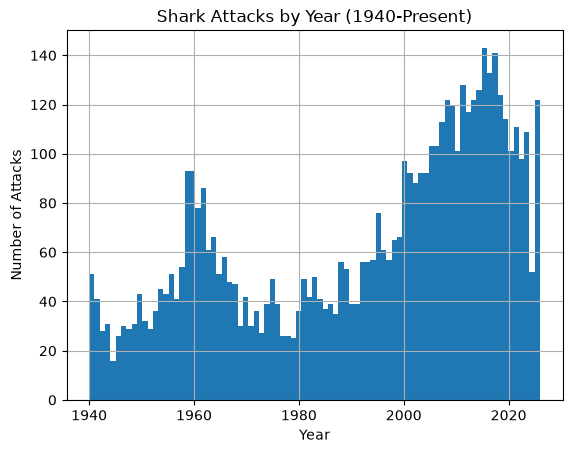

Sex
M        0.871883
F        0.125156
M        0.001091
?        0.000312
F        0.000312
N        0.000312
M F      0.000156
 M       0.000156
m        0.000156
lli      0.000156
M x 2    0.000156
.        0.000156
Name: proportion, dtype: float64
The proportion of victims who are male is 87.19%
Type
Unprovoked             5150
Provoked                640
Invalid                 549
Watercraft              353
Sea Disaster            236
Questionable             27
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type
Unprovoked    5152
Unknown       1192
Provoked       642
Name: count, dtype: int64
The proportion of attacks that are unprovoked is 73.75%


In [61]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================================
# Question 1, Part 1: Airbnb data
# ================================

# look at airbnb data
df = pd.read_csv('data/airbnb_hw.csv')
print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

print(df.head())

# clean Price column: remove $ and commas, convert to float
df["Price"] = df["Price"].astype(str).replace(r'[\$,]', '', regex=True).astype(float)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print(df.head())

print("Missing Price values:", df['Price'].isna().sum())


# ================================
# Question 1, Part 2: MN police use-of-force data
# ================================

# examine Minnesota police data
df = pd.read_csv('data/mn_police_use_of_force.csv')
print("df.shape:")
print(df.shape, '\n')

print(df.head())

# check for nulls/na's in the subject_injury column
print("Missing subject_injury values:", df['subject_injury'].isnull().sum())

# proportion of rows with null values in the subject_injury column
missing_count = df['subject_injury'].isna().sum()
total_rows = len(df)
proportion_missing = missing_count / total_rows
print(f"Proportion of missing subject_injury values: {proportion_missing:.2%}")

# About 71% of rows in the subject_injury column are missing values. This is a
# very large amount of missing data, which is concerning as it limits the kind
# of preparation the precinct can take to prepare for the most common injuries.

# clean subject_injury by replacing any nulls with "Not known"
df['subject_injury'] = df['subject_injury'].fillna('Not known')

# cross-tabulate subject_injury with force_type to check for patterns in missingness
injury_force_crosstab = pd.crosstab(df['subject_injury'], df['force_type'])
print(injury_force_crosstab)

# This shows that "Not known" injuries are most common when the force type
# involves either bodily force or a chemical irritant (likely something like
# pepper spray). Those injuries are probably more minor than ones from a
# firearm or improvised weapon, so officers may be less likely to log an
# injury outcome. They may also be less likely to report an injury if they
# feel it would reflect poorly on them — though that's speculative and would
# need more data and analysis to confirm.


# ================================
# Question 2: Shark attack data
# ================================

# examine the shark attack data
df = pd.read_excel('data/GSAF5.xls')

# drop columns that are entirely empty
df = df.dropna(axis=1, how='all')

print(df.head())

# clean Year column: convert to nullable integer type
df['Year'] = df['Year'].astype('Int64')

# drop zero years — the dataset does not have a recorded date for these
df = df[df['Year'] != 0]

# display range of years
print("Year range:", df['Year'].min(), "-", df['Year'].max())

# filter to attacks since 1940
df_since_1940 = df[df['Year'] >= 1940]
print(df_since_1940.head())

# examine trends since 1940
print('Year summary stats (since 1940):\n', df_since_1940['Year'].describe(), '\n')

df_since_1940['Year'].hist(bins=85)
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Shark Attacks by Year (1940-Present)')
plt.show()

# determine proportion of victims who are male
sex_proportion = df['Sex'].value_counts(normalize=True)
print(sex_proportion)
male_proportion = sex_proportion.loc['M']
print(f"The proportion of victims who are male is {male_proportion:.2%}")

# clean the Type column
# check what values currently exist
print(df['Type'].value_counts())

# strip whitespace so variants like " Provoked" match "Provoked"
df['Type'] = df['Type'].str.strip()

# map messy/inconsistent values into three clean categories:
# Provoked, Unprovoked, Unknown
df['Type'] = df['Type'].replace({
    'Unprovoked': 'Unprovoked',
    'UNprovoked': 'Unprovoked',
    'unprovoked': 'Unprovoked',
    'Provoked': 'Provoked',
    'Invalid': 'Unknown',
    'Watercraft': 'Unknown',
    'Sea Disaster': 'Unknown',
    'Questionable': 'Unknown',
    'Boat': 'Unknown',
    '?': 'Unknown',
    'Unconfirmed': 'Unknown',
    'Unverified': 'Unknown',
    'Under investigation': 'Unknown',
})

# catch any remaining leftovers (including NaN) not already mapped
valid_values = ['Provoked', 'Unprovoked']
df.loc[~df['Type'].isin(valid_values), 'Type'] = 'Unknown'

print(df['Type'].value_counts())

# determine proportion of attacks that are unprovoked
type_proportion = df['Type'].value_counts(normalize=True)
unprovoked_proportion = type_proportion.loc['Unprovoked']
print(f"The proportion of attacks that are unprovoked is {unprovoked_proportion:.2%}")

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

In [ ]:
print("AI's biggest contribution was that it helped the final output look much cleaner than when I originally had it displayed. Overall, I found the first go at the assignment quite challenging, probably since I have not coded anything in almost a year, so diving back into repositories and codestacks was quite the throw back. AI is such a powerful tool when it comes to coding, but it's analysis is generally pretty surface-level, although that is definitely changing. I have noticed a big improvement in data analysis capabilities of AI models from when I started messing around with them a few years ago to today. Claude especially tends to pick up on nuances that I would have otherwise missed, and for that reason, I try and spend as much time looking at datasets from all angles before resporting to having an AI look over my shoulder. As they are trained to always have a solution to a problem, I have found that I may ask it to look for another scope of analysis and what it throws back at me has almost zero relevance to the actual question at hand. That I think is where the real limit lies. It needs to be right and it needs to keep you engaged, and therefore it does not know when to stop and say that the work here is done. Yet, overall, for basic data cleaning and analysis, I find the tools the be very useful.")